# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data
!kaggle datasets download -d rahmasleam/flowers-dataset -p data

!unzip -q data/flowers-dataset.zip -d data/flowers_dataset


cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rahmasleam/flowers-dataset
License(s): apache-2.0
100% 219M/219M [00:16<00:00, 14.1MB/s]



In [12]:
import tensorflow as tf

from tensorflow.keras import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt
import pathlib
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


IMG_SIZE = (128, 128)
BATCH_SIZE = 32
DATA_DIR = pathlib.Path("data/flowers_dataset")

In [ ]:
#  цветной датасет без меток
train_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels=None,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
)

val_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels=None,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
)

Found 3670 files.
Using 2936 files for training.
Found 3670 files.
Using 734 files for validation.


In [ ]:
def make_gray_color_pair(batch_rgb):
    #  в [0, 1]
    batch_rgb = tf.cast(batch_rgb, tf.float32) / 255.0

    gray = tf.image.rgb_to_grayscale(batch_rgb)
    return gray, batch_rgb  # (X, y)

In [ ]:
train_ds = train_rgb_ds.map(make_gray_color_pair)
val_ds   = val_rgb_ds.map(make_gray_color_pair)

# Оптимизация ввода
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
inputs = Input(shape=IMG_SIZE + (1,))  # ч/б

#  Encoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

#  Decoder
x = UpSampling2D((2, 2))(encoded)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)

x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)

x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)

# 3 канала на выходе
outputs = Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,379 (1.27 MB)

 Trainable params: 333,379 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:

EPOCHS = 50

checkpoint_cb = ModelCheckpoint(
    "best_colorization.h5",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reducelr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint_cb, earlystop_cb, reducelr_cb]

history = autoencoder.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

NameError: name 'autoencoder' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step


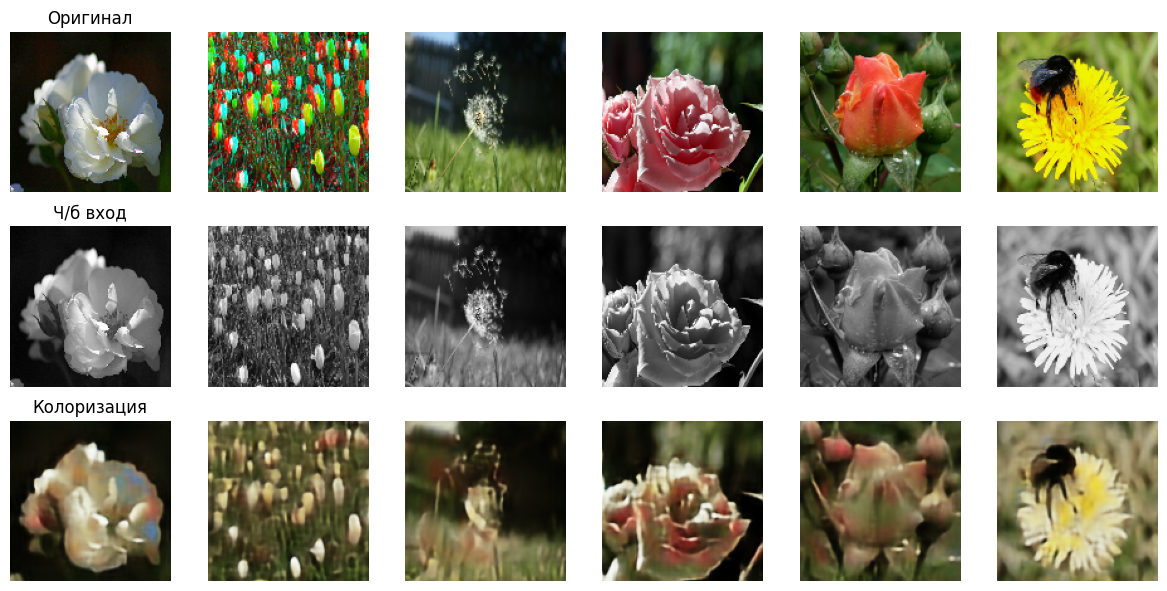

In [ ]:
import itertools

# Берём один батч из валидации
for gray_batch, color_batch in val_ds.take(1):
    preds = autoencoder.predict(gray_batch)
    break

# Переводим тензоры в numpy
gray_batch_np  = gray_batch.numpy()
color_batch_np = color_batch.numpy()
preds_np       = preds

n = 6

plt.figure(figsize=(12, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(color_batch_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Оригинал")

    ax = plt.subplot(3, n, i + 1 + n)
    # Убираем последний канал (H,W,1) -> (H,W)
    plt.imshow(gray_batch_np[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Ч/б вход")


    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(preds_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Колоризация")

plt.tight_layout()
plt.show()

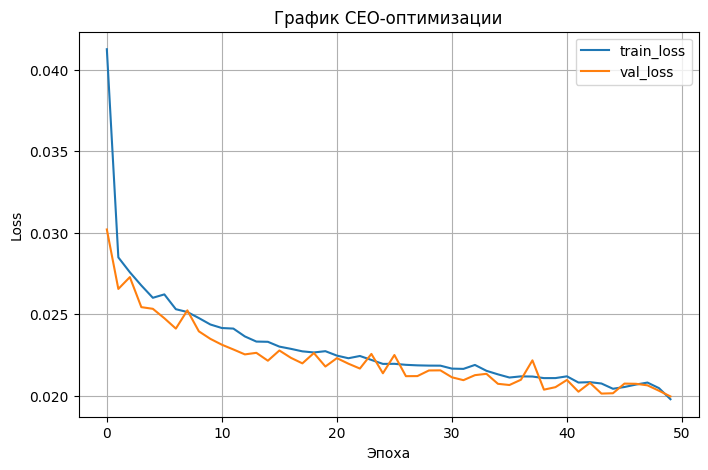

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("График СЕО-оптимизации")
plt.legend()
plt.grid(True)
plt.show()

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data
!kaggle datasets download -d waseemalastal/eurosat-rgb-dataset -p data

!unzip -q data/eurosat-rgb-dataset.zip -d data/eurosat_rgb

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/waseemalastal/eurosat-rgb-dataset
License(s): unknown
100% 89.9M/89.9M [00:07<00:00, 11.9MB/s]



In [ ]:
IMG_SIZE = (64, 64)     # можно 64x64, чтобы модель обучалась быстрее
BATCH_SIZE = 32
DATA_DIR = pathlib.Path("data/eurosat_rgb")

In [ ]:
train_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels=None,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
)

val_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels=None,
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
)

Found 27000 files.
Using 21600 files for training.
Found 27000 files.
Using 5400 files for validation.


In [ ]:
def add_realistic_noise(batch_rgb, sigma=0.1, speckle=0.1):
    #  в [0,1]
    x = tf.cast(batch_rgb, tf.float32) / 255.0

    # аддитивный гауссовский шум
    gauss = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=sigma)
    x_noisy = x + gauss

    # «спекл»: шум пропорционален яркости пикселя
    speckle_noise = x * tf.random.normal(tf.shape(x), mean=0.0, stddev=speckle)
    x_noisy = x_noisy + speckle_noise

    # обрезаем в допустимый диапазон
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

def make_noisy_pair(batch_rgb):
    clean = tf.cast(batch_rgb, tf.float32) / 255.0
    noisy = add_realistic_noise(batch_rgb)
    return noisy, clean  # (X, y)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_rgb_ds.map(make_noisy_pair).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_rgb_ds.map(make_noisy_pair).cache().prefetch(AUTOTUNE)

In [ ]:
inputs = Input(shape=IMG_SIZE + (3,))  # noisy RGB

#  Encoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

#  Decoder
x = UpSampling2D((2, 2))(encoded)
x = Conv2D(128, (3, 3), activation="relu", padding="same")(x)

x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)

x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)

# 3 канала на выходе
outputs = Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)

denoise_autoencoder = Model(inputs, outputs)
denoise_autoencoder.compile(optimizer="adam", loss="mse")

denoise_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoint_cb = ModelCheckpoint(
    "best_denoise_eurosat.h5",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reducelr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint_cb, earlystop_cb, reducelr_cb]

EPOCHS = 50

history = denoise_autoencoder.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0072
Epoch 1: val_loss improved from None to 0.00228, saving model to best_denoise_eurosat.h5



Epoch 1: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - loss: 0.0040 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0021
Epoch 2: val_loss improved from 0.00228 to 0.00180, saving model to best_denoise_eurosat.h5



Epoch 2: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0020 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 3/50
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0018
Epoch 3: val_loss improved from 0.00180 to 0.00162, saving model to best_denoise_eurosat.h5



Epoch 3: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0018 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0016
Epoch 4: val_loss improved from 0.00162 to 0.00153, saving model to best_denoise_eurosat.h5



Epoch 4: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0016 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 5/50
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015
Epoch 5: val_loss improved from 0.00153 to 0.00148, saving model to best_denoise_eurosat.h5


...


Epoch 45: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 9.9325e-04 - val_loss: 0.0010 - learning_rate: 1.5625e-05
Epoch 46/50
672/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.9222e-04
Epoch 46: val_loss improved from 0.00104 to 0.00104, saving model to best_denoise_eurosat.h5



Epoch 46: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 9.9298e-04 - val_loss: 0.0010 - learning_rate: 1.5625e-05
Epoch 47/50
673/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.9702e-04
Epoch 47: val_loss did not improve from 0.00104
675/675 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 9.9278e-04 - val_loss: 0.0010 - learning_rate: 1.5625e-05
Epoch 48/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.8834e-04
Epoch 48: val_loss improved from 0.00104 to 0.00104, saving model to best_denoise_eurosat.h5



Epoch 48: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 9.9250e-04 - val_loss: 0.0010 - learning_rate: 1.5625e-05
Epoch 49/50
674/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.9397e-04
Epoch 49: val_loss improved from 0.00104 to 0.00104, saving model to best_denoise_eurosat.h5



Epoch 49: finished saving model to best_denoise_eurosat.h5

Epoch 49: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 9.9223e-04 - val_loss: 0.0010 - learning_rate: 1.5625e-05
Epoch 50/50
672/675 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 9.9147e-04
Epoch 50: val_loss improved from 0.00104 to 0.00104, saving model to best_denoise_eurosat.h5



Epoch 50: finished saving model to best_denoise_eurosat.h5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 9.9133e-04 - val_loss: 0.0010 - learning_rate: 7.8125e-06
Restoring model weights from the end of the best epoch: 50.


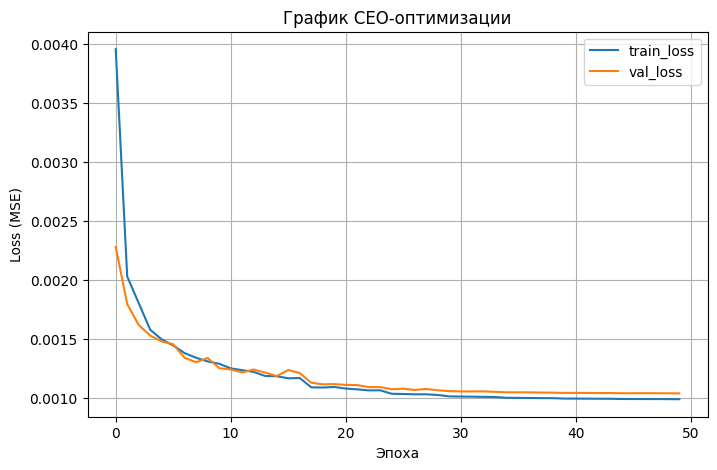

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss (MSE)")
plt.title("График СЕО-оптимизации")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


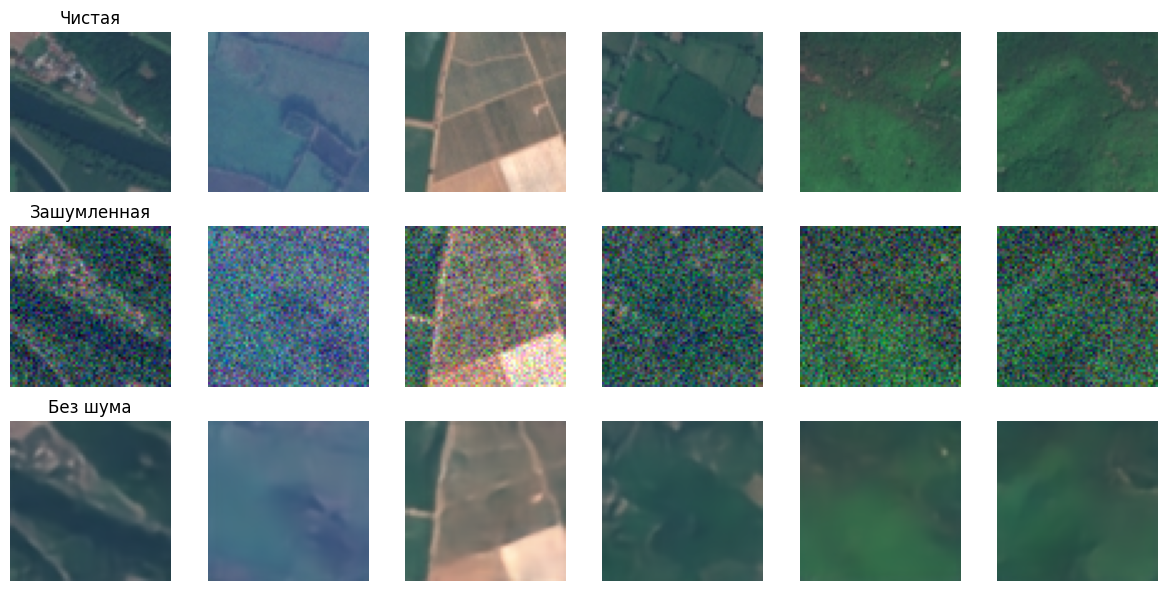

In [ ]:
#  один батч из валидации
for noisy_batch, clean_batch in val_ds.take(1):
    preds = denoise_autoencoder.predict(noisy_batch)
    break

noisy_np  = noisy_batch.numpy()
clean_np  = clean_batch.numpy()
preds_np  = preds

n = 6

plt.figure(figsize=(12, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(clean_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Чистая")

    # Зашумлённый вход
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Зашумленная")

    # Восстановленный автоэнкодером
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(preds_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Без шума")

plt.tight_layout()
plt.show()

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

In [3]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data
!kaggle datasets download -d soumikrakshit/div2k-high-resolution-images -p data

!unzip -q data/div2k-high-resolution-images.zip -d data/div2k

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/div2k-high-resolution-images
License(s): unknown
100% 3.71G/3.71G [00:42<00:00, 93.9MB/s]



In [13]:
HR_SIZE = (512, 512)
LR_SIZE = (256, 256)
BATCH_SIZE = 8

DATA_DIR = pathlib.Path("data/div2k")

In [14]:
HR_DIR = DATA_DIR

# Загружаем и сразу ресайзим до 512×512
base_ds = tf.keras.utils.image_dataset_from_directory(
    HR_DIR,
    labels=None,
    color_mode="rgb",
    image_size=HR_SIZE,       # это будет Y
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 900 files.


In [15]:
def make_lr_hr_pair(batch_hr):
    # HR как float32 в [0,1]
    hr = tf.cast(batch_hr, tf.float32) / 255.0   # (B, 512, 512, 3)
    # даунскейл HR в 256×256 bicubic-интерполяцией
    lr = tf.image.resize(hr, LR_SIZE, method="bicubic")
    return lr, hr  # X, Y

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

ds = base_ds.map(make_lr_hr_pair)
ds = ds.cache().shuffle(400).prefetch(AUTOTUNE)

train_size = 0.9
train_batches = int(train_size * tf.data.experimental.cardinality(ds).numpy())

train_ds = ds.take(train_batches)
val_ds   = ds.skip(train_batches)

In [17]:
inputs = Input(shape=LR_SIZE + (3,))  # (256, 256, 3)

#  Encoder (извлекаем признаки на низком разрешении)
x = Conv2D(64, (3, 3), padding="same", activation="relu")(inputs)
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2), padding="same")(x)  # 128×128

x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2), padding="same")(x)  # 64×64

x = Conv2D(256, (3, 3), padding="same", activation="relu")(x)

#  Decoder (восстанавливаем детали и увеличиваем размер)
x = UpSampling2D((2, 2))(x)                   # 128×128
x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)

x = UpSampling2D((2, 2))(x)                   # 256×256
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)

# Финальный апскейл 256 → 512
x = UpSampling2D((2, 2))(x)                   # 512×512
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)

outputs = Conv2D(3, (3, 3), padding="same", activation="sigmoid")(x)

sr_autoencoder = Model(inputs, outputs)
sr_autoencoder.compile(optimizer="adam", loss="mse")

sr_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 256, 256, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 512, 512, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 512, 512, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 512, 512, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,235 (3.11 MB)

 Trainable params: 815,235 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
checkpoint_cb = ModelCheckpoint(
    "best_sr_autoencoder.h5",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reducelr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint_cb, earlystop_cb, reducelr_cb]

EPOCHS = 50

history = sr_autoencoder.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 0.0469
Epoch 1: val_loss improved from None to 0.01178, saving model to best_sr_autoencoder.h5



Epoch 1: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 132s 399ms/step - loss: 0.0277 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - loss: 0.0131
Epoch 2: val_loss improved from 0.01178 to 0.01128, saving model to best_sr_autoencoder.h5



Epoch 2: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 59s 587ms/step - loss: 0.0124 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - loss: 0.0102
Epoch 3: val_loss improved from 0.01128 to 0.00956, saving model to best_sr_autoencoder.h5



Epoch 3: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - loss: 0.0100 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0100
Epoch 4: val_loss did not improve from 0.00956
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - loss: 0.0098 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0099
Epoch 5: val_loss improved from 0.00956 to 0.00852, saving model to best_sr_autoencoder.h5



Epoch 5: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - loss: 0.0093 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.0090
Epoch 6: val_loss did not improve from 0.00852
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 322ms/step - loss: 0.0088 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.0079
Epoch 7: val_loss improved from 0.00852 to 0.00719, saving model to best_sr_autoencoder.h5


...


Epoch 11: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - loss: 0.0073 - val_loss: 0.0064 - learning_rate: 5.0000e-04
Epoch 12/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.0070
Epoch 12: val_loss did not improve from 0.00645
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - loss: 0.0068 - val_loss: 0.0071 - learning_rate: 5.0000e-04
Epoch 13/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 0.0069
Epoch 13: val_loss improved from 0.00645 to 0.00635, saving model to best_sr_autoencoder.h5



Epoch 13: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - loss: 0.0068 - val_loss: 0.0063 - learning_rate: 5.0000e-04
Epoch 14/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0065
Epoch 14: val_loss improved from 0.00635 to 0.00602, saving model to best_sr_autoencoder.h5



Epoch 14: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - loss: 0.0065 - val_loss: 0.0060 - learning_rate: 5.0000e-04
Epoch 15/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0068
Epoch 15: val_loss did not improve from 0.00602
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - loss: 0.0066 - val_loss: 0.0068 - learning_rate: 5.0000e-04
Epoch 16/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0067
Epoch 16: val_loss did not improve from 0.00602
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - loss: 0.0064 - val_loss: 0.0074 - learning_rate: 5.0000e-04
Epoch 17/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 0.0066
Epoch 17: val_loss improved from 0.00602 to 0.00593, saving model to best_sr_autoencoder.h5



Epoch 17: finished saving model to best_sr_autoencoder.h5

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - loss: 0.0065 - val_loss: 0.0059 - learning_rate: 5.0000e-04
Epoch 18/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0063
Epoch 18: val_loss improved from 0.00593 to 0.00526, saving model to best_sr_autoencoder.h5



Epoch 18: finished saving model to best_sr_autoencoder.h5
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - loss: 0.0063 - val_loss: 0.0053 - learning_rate: 2.5000e-04
Epoch 19/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0059
Epoch 19: val_loss did not improve from 0.00526
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - loss: 0.0061 - val_loss: 0.0053 - learning_rate: 2.5000e-04
Epoch 20/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 0.0058
Epoch 20: val_loss did not improve from 0.00526
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - loss: 0.0061 - val_loss: 0.0060 - learning_rate: 2.5000e-04
Epoch 21/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 0.0059
Epoch 21: val_loss did not improve from 0.00526

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
101/101 ━━━━━━━━━━━━━━━━━━━━ 33s 325ms/step - loss: 0.0060 - val_loss: 0.0056 - learning_rate: 2.5000e-04
Epoch 22/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - loss: 0.0060
Epoch 22: val_l

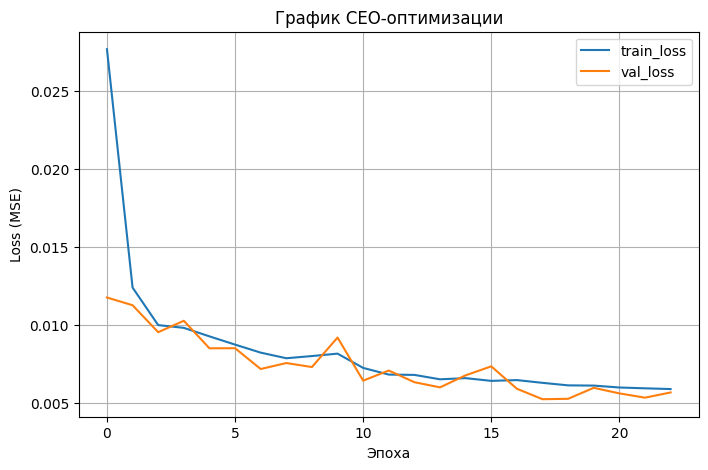

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss (MSE)")
plt.title("График СЕО-оптимизации")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step


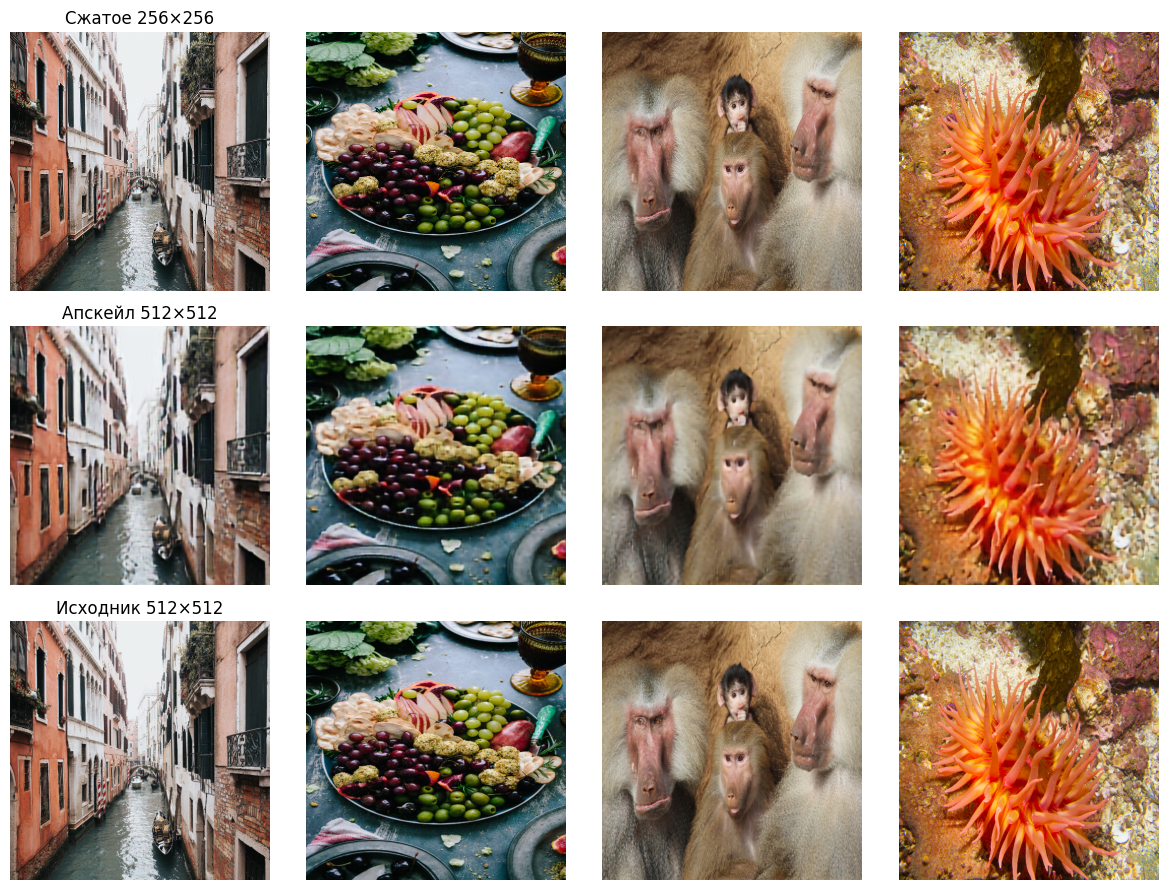

In [20]:
#  один батч из валидации
for lr_batch, hr_batch in val_ds.take(1):
    preds = sr_autoencoder.predict(lr_batch)
    break

lr_np  = lr_batch.numpy()
hr_np  = hr_batch.numpy()
preds_np = preds

n = 4

plt.figure(figsize=(12, 9))
for i in range(n):
    # LR (вход 256×256)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(lr_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Сжатое 256×256")

    # SR (предсказание 512×512)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(preds_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Апскейл 512×512")

    # HR (таргет 512×512)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(hr_np[i])
    plt.axis("off")
    if i == 0:
        ax.set_title("Исходник 512×512")

plt.tight_layout()
plt.show()

Исходное разрешение файла: 512×512
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


HR shape: (512, 512, 3)
LR shape: (256, 256, 3)
SR shape: (512, 512, 3)


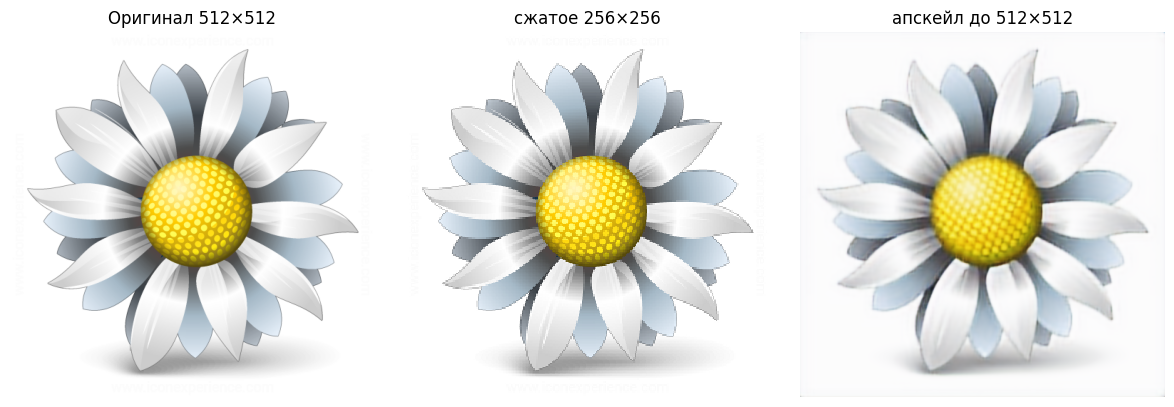

In [21]:
from tensorflow.keras.utils import array_to_img


image_path = "/content/photo.png"

HR_SIZE = (512, 512)
LR_SIZE = (256, 256)

#  к 512×512
raw = tf.io.read_file(image_path)
img = tf.image.decode_image(raw, channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)  # в [0,1]
img.set_shape([None, None, 3])

orig_h, orig_w = img.shape[0], img.shape[1]
print(f"Исходное разрешение файла: {orig_w}×{orig_h}")

hr = tf.image.resize(img, HR_SIZE, method="bicubic")  #  512×512

# Сжимаем до 256×256 и апскейлим  обратно до 512×512
lr = tf.image.resize(hr, LR_SIZE, method="bicubic")           # 256×256
lr_batch = tf.expand_dims(lr, axis=0)                         # (1,256,256,3)

sr_pred = sr_autoencoder.predict(lr_batch)[0]                 # (512,512,3), np.ndarray
sr_pred = sr_pred.clip(0.0, 1.0)

print("HR shape:", hr.shape)
print("LR shape:", lr.shape)
print("SR shape:", sr_pred.shape)


plt.figure(figsize=(12, 4))


ax = plt.subplot(1, 3, 1)
plt.imshow(hr.numpy())
plt.axis("off")
ax.set_title("Оригинал 512×512")

ax = plt.subplot(1, 3, 2)
plt.imshow(lr.numpy(), interpolation="nearest")
plt.axis("off")
ax.set_title("сжатое 256×256")

ax = plt.subplot(1, 3, 3)
plt.imshow(sr_pred)
plt.axis("off")
ax.set_title("апскейл до 512×512")

plt.tight_layout()
plt.show()